# Step 1

In [278]:
!pip install folium

In [279]:
import pandas as pd

df = pd.read_csv("/content/20k.csv", encoding='latin1')

# step 2

In [280]:
df = df.drop_duplicates()

df = df.fillna({
    'payload': '',
})

df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")

# step 3
IP address preprocessing

Options (if you ahve another idea you can do that too):
  *   Split IP addresses into 4 numerical components, or
  *   Convert to integer representation (using Python’s ipaddress library).

encode proxy

In [281]:
def get_ip_encoding(ipv4):
    oct1, oct2, oct3, oct4 = ipv4.split('.')
    return  int(oct1), int(oct2), int(oct3), int(oct4)

df[['src_oct1', 'src_oct2', 'src_oct3', 'src_oct4']] = df["src_ip"].apply(get_ip_encoding).apply(pd.Series)
df[['dst_oct1', 'dst_oct2', 'dst_oct3', 'dst_oct4']] = df["dst_ip"].apply(get_ip_encoding).apply(pd.Series)

In [282]:
df.replace({True: 1, False: 0}, inplace=True)

/tmp/ipython-input-3673826116.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({True: 1, False: 0}, inplace=True)


# Step 4
Location based features processing and analysis

*   Preprocess longitude and latitude from the geo_string feature
*   Encode country/city/region
*   Visualize frequency location based, and attack network
    *   Try using folium for a visual representation of the attack network (you will have to install it)
    *   Recommended: select 300-500 samples to avoid crowding on the map, and long running time
    *   !pip install folium











<details>
  <summary>Click to reveal comment</summary>

*   Frequency based encoding
*   Onehot Encoded
*   LLM based encoding (sentence transformer)

</details>







In [283]:
# frequency based encoding of country
src_country_counts = df['src_country'].value_counts()
df['src_country_freq'] = df['src_country'].map(src_country_counts)
dst_country_counts = df['dst_country'].value_counts()
df['dst_country_freq'] = df['dst_country'].map(dst_country_counts)

df = df.drop(['src_country', 'dst_country'], axis=1)

In [284]:
df["src_geo_str"] = df["src_geo_str"].str.split("|").apply(lambda lst: [float(x) for x in lst])
df["dst_geo_str"] = df["dst_geo_str"].str.split("|").apply(lambda lst: [float(x) for x in lst])

In [285]:
import numpy as np
def get_lat_lon(geo_list):
    lon = float(geo_list[0])
    lat = float(geo_list[1])
    lat_sin = np.sin(np.radians(lat))
    lat_cos = np.cos(np.radians(lat))
    lon_sin = np.sin(np.radians(lon))
    lon_cos = np.cos(np.radians(lon))

    return [lat, lon, lat_sin, lat_cos, lon_sin, lon_cos]

df[["src_lat","src_lon","src_lat_sin", "src_lat_cos", "src_lon_sin", "src_lon_cos"]] = df["src_geo_str"].apply(get_lat_lon).apply(pd.Series)
df[["dst_lat","dst_lon","dst_lat_sin", "dst_lat_cos", "dst_lon_sin", "dst_lon_cos"]] = df["dst_geo_str"].apply(get_lat_lon).apply(pd.Series)

df.drop(["src_geo_str", "dst_geo_str"], inplace=True, axis=1)

In [286]:
import folium

m = folium.Map(location=[20, 0], zoom_start=2)
n_to_show = 350  # adjust based on performance

sample = df[["src_lat", "src_lon", "src_ip", "dst_lat", "dst_lon", "dst_ip"]].dropna().sample(n=min(n_to_show, len(df)))

for row in sample.itertuples(index=False):
    lat, lon, ip, dlat, dlon, dip = row

    folium.CircleMarker(
        location=(lat, lon),
        radius=5,
        color='red',
        fill=True,
        fill_color='purple',
        fill_opacity=0.7,
        popup=f"Source IP: {ip}"
    ).add_to(m)

    folium.PolyLine(
        locations=[(lat, lon), (dlat, dlon)],
        color='brown',
        weight=2,
        opacity=0.3
    ).add_to(m)

    folium.CircleMarker(
        location=(dlat, dlon),
        radius=6,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.7,
        popup=f"Destination IP: {dip}"
    ).add_to(m)
m

# step 5
time features

In [287]:
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['weekday'] = df['timestamp'].dt.weekday
df['minute'] = df['timestamp'].dt.minute
df["second"] = df['timestamp'].dt.second

# Sort by IP and timestamp
df = df.sort_values(by=['src_ip', 'timestamp'])

# inter-arrival time per IP
df['iat'] = df.groupby('src_ip')['timestamp'].diff().dt.total_seconds()
df['iat'] = df['iat'].fillna(0)

# Step 6

Port/protocol analysis


*   onehot encode protocols, or frequency based or another method you see fit
*   analyse Port and protocol behaviours



In [288]:
protocol_categories = {
    'web': ['http', 'https'],
    'file_transfer': ['ftp', 'smb'],
    'remote_access': ['ssh', 'telnet', 'rdp', 'vnc', 'teamviewer', 'mikrotik'],
    'email': ['smtp', 'smtps', 'imap', 'imaps', 'pop3', 'pop3s'],
    'database': ['redis', 'mongodb', 'memcached', 'elasticsearch'],
    'messaging': ['mqtt', 'mqtts', 'amqp', 'amqps'],
    'vpn': ['openvpn'],
    'iot': ['tr-069', 'hisilicon'],
    'other': ['other']
}

inv_protocol_categories = {el: k for k, lst in protocol_categories.items() for el in lst}

df["protocol_category"] = df["protocol"].apply(lambda x: inv_protocol_categories[x])

In [289]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', handle_unknown="ignore").fit(df[["protocol_category"]])

df[ohe.get_feature_names_out()] = ohe.transform(df[["protocol_category"]]).toarray().astype(int)
df.drop(columns=["protocol_category", "protocol"], inplace=True)

# step 7
payload processing

In [290]:
df["payload_4kb_hex"].apply(lambda x: bytes.fromhex(x))

,payload_4kb_hex
1207,b'\x00\x00\x00T\xef\xbf\xbdSMBr\x00\x00\x00\x0...
1218,b'\x00\x00\x00\xef\xbf\xbd\xef\xbf\xbdSMBr\x00...
4636,b'\x00\x00\x00E\xef\xbf\xbdSMBr\x00\x00\x00\x0...
4638,b'\x00\x00\x00E\xef\xbf\xbdSMBr\x00\x00\x00\x0...
4641,b'\x00\x00\x00E\xef\xbf\xbdSMBr\x00\x00\x00\x0...
...,...
14713,b';\x00\x00\x00\xcf\x92\xef\xbf\xbd\xef\xbf\xb...
304,b'\r\n'
307,b'\x03\x00\x00\x13\x0e\xef\xbf\xbd\x00\x00\x00...
2467,b'\r\n'


In [291]:
from scipy.stats import entropy

def get_payload_features(payload):
    default = {'length': 0, 'unique_bytes': 0, 'entropy': 0.0,
               'mean_byte': 0.0, 'std_byte': 0.0}
    if not isinstance(payload, str) or len(payload) == 0:
        return default
    try:
        data = bytes.fromhex(payload)
    except ValueError:
        return default
    length = len(data)
    if length == 0:
        return default
    arr = np.frombuffer(data, dtype=np.uint8)
    counts = np.bincount(arr, minlength=256)
    probs = counts / length

    probs = probs[probs > 0]
    ent = entropy(probs, base=2)
    mean = float(arr.mean())
    std = float(arr.std())
    return {
        'length': length,
        'unique_bytes': int(np.count_nonzero(counts)),
        'entropy': float(ent),
        'mean_byte': mean,
        'std_byte': std
    }

payload_feats = ['pl_length', 'pl_unique_bytes', 'pl_entropy', 'pl_mean_byte', 'pl_std_byte']
df[payload_feats] = df["payload_4kb_hex"].apply(get_payload_features).apply(pd.Series)

# Step 8
Cluster the data to visualise the attack groups made

You can use:
*   K-means for base clusters
*   HDBScan for hierarchical density based clustering
*   Other methods you know of if you want

Evaluation of the clusters can be done visually and with the sillouette score

In [292]:
df.reset_index(drop=True, inplace=True)

In [293]:
cluster_df = df.drop(columns=["payload_4kb_hex","src_ip", "dst_ip", "src_countryCode", "src_city", "src_as", "src_regionName", "dst_countryCode", "dst_city", "dst_as","dst_regionName"])


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


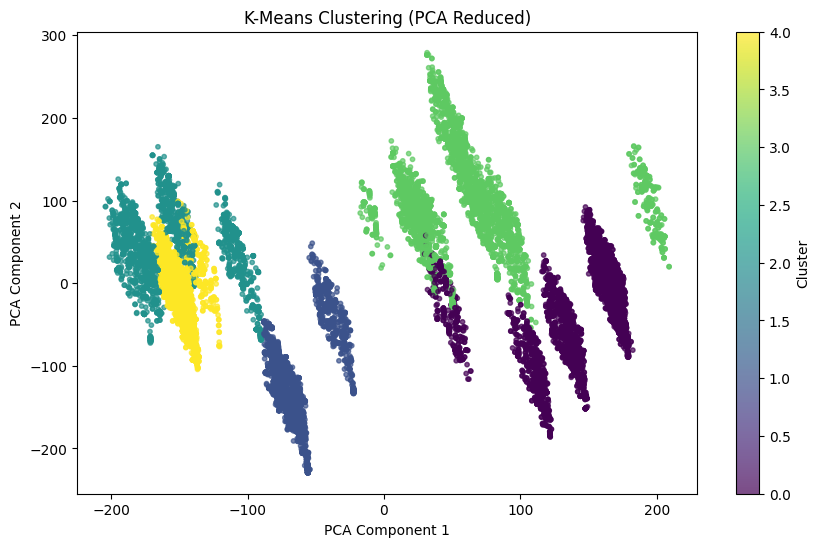

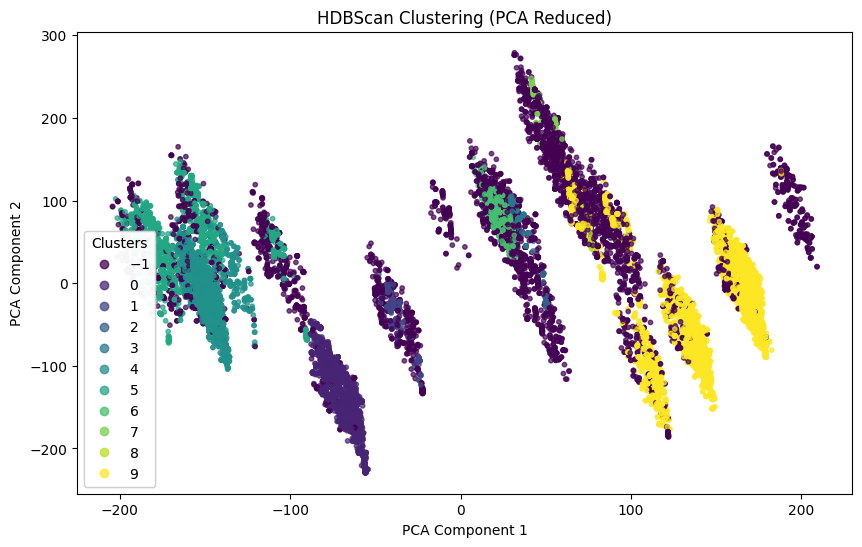

In [294]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import hdbscan


features_to_scale = [
    'src_port', 'dst_port', 'src_country_freq',
    'dst_country_freq', 'src_lat_sin', 'src_lat_cos', 'src_lon_sin',
    'src_lon_cos', 'dst_lat_sin', 'dst_lat_cos', 'dst_lon_sin', 'dst_lon_cos',
    'iat', 'pl_length', 'pl_unique_bytes', 'pl_entropy', 'pl_mean_byte', 'pl_std_byte'
]

features_to_keep_unscaled = [
    'src_proxy', 'dst_proxy', 'src_lat', 'src_lon', 'dst_lat', 'dst_lon',
    'hour', 'day', 'weekday', 'minute', 'second',
    'protocol_category_email', 'protocol_category_file_transfer',
    'protocol_category_iot', 'protocol_category_messaging',
    'protocol_category_other', 'protocol_category_remote_access',
    'protocol_category_vpn', 'protocol_category_web', 'src_oct1', 'src_oct2', 'src_oct3', 'src_oct4',
    'dst_oct1', 'dst_oct2', 'dst_oct3', 'dst_oct4'
]

df_scaled_features = cluster_df[features_to_scale]
df_unscaled_features = cluster_df[features_to_keep_unscaled]


scaler = QuantileTransformer()
X_scaled = scaler.fit_transform(df_scaled_features)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_to_scale, index=df_scaled_features.index)
X_combined = pd.concat([X_scaled_df, df_unscaled_features], axis=1)

# K-means Clustering
kmeans = KMeans(n_clusters=5, n_init=10)
kmeans_clusters = kmeans.fit_predict(X_combined)
cluster_df['kmeans_cluster'] = pd.Series(kmeans_clusters, index=X_combined.index)


# HDBScan Clustering
hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=100, prediction_data=True)
hdbscan_clusters = hdbscan_clusterer.fit_predict(X_combined)
cluster_df['hdbscan_cluster'] = pd.Series(hdbscan_clusters, index=X_combined.index)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_combined)

plt.figure(figsize=(10, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=kmeans_clusters, cmap='viridis', alpha=0.7, s=10)
plt.title('K-Means Clustering (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

plt.figure(figsize=(10, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=hdbscan_clusters, cmap='viridis', alpha=0.7, s=10)
plt.title('HDBScan Clustering (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
legend1 = plt.legend(*scatter.legend_elements(),
                    loc="lower left", title="Clusters")
plt.gca().add_artist(legend1)
plt.show()

Average Silhouette Score for K-Means: 0.17
Average Silhouette Score for HDBScan (excluding noise): 0.19


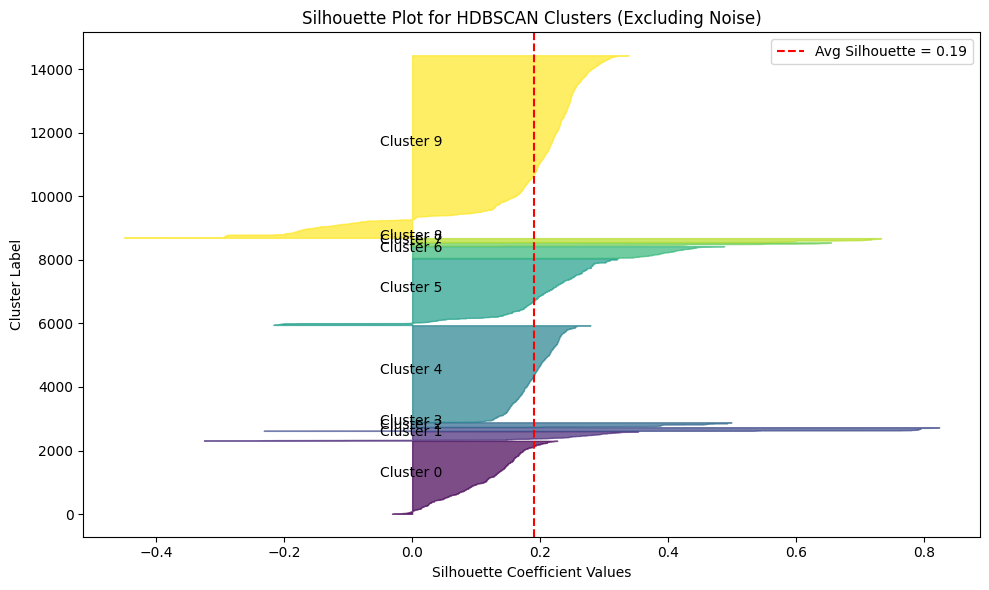

In [295]:
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

# Evaluate K-means clustering
kmeans_silhouette_avg = silhouette_score(X_combined, kmeans_clusters)
print(f"Average Silhouette Score for K-Means: {kmeans_silhouette_avg:.2f}")

mask = hdbscan_clusters != -1
X_filtered = X_combined[mask]
labels_filtered = hdbscan_clusters[mask]

if len(np.unique(labels_filtered)) > 1:
    hdbscan_silhouette_avg = silhouette_score(X_filtered, labels_filtered)
    print(f"Average Silhouette Score for HDBScan (excluding noise): {hdbscan_silhouette_avg:.2f}")

    silhouette_vals = silhouette_samples(X_filtered, labels_filtered)

    sorted_idx = np.argsort(labels_filtered)
    sorted_silhouette_vals = silhouette_vals[sorted_idx]
    sorted_cluster_labels = labels_filtered[sorted_idx]

    fig, ax = plt.subplots(figsize=(10, 6))
    y_lower = 10
    unique_labels = np.unique(labels_filtered)

    for label in unique_labels:
        label_sil_vals = sorted_silhouette_vals[sorted_cluster_labels == label]
        label_sil_vals.sort()
        y_upper = y_lower + len(label_sil_vals)

        color = plt.cm.viridis(float(label) / (len(unique_labels) - 1))
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, label_sil_vals, facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * len(label_sil_vals), f'Cluster {label}')
        y_lower = y_upper + 10

    ax.axvline(hdbscan_silhouette_avg, color="red", linestyle="--", label=f"Avg Silhouette = {hdbscan_silhouette_avg:.2f}")
    ax.set_title("Silhouette Plot for HDBSCAN Clusters (Excluding Noise)")
    ax.set_xlabel("Silhouette Coefficient Values")
    ax.set_ylabel("Cluster Label")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Cannot compute silhouette score for HDBScan as there is only one cluster (excluding noise).")

# Step 9
grouping dataset for concise data and less noise

group by (These are suggestions you can do as you please):
*   src IP
*   dst IP
*   iter-arrival time (time between attack; other wise you will consider any attack from same src IP to the same dst IP to be part of the same attack timing)
*   port





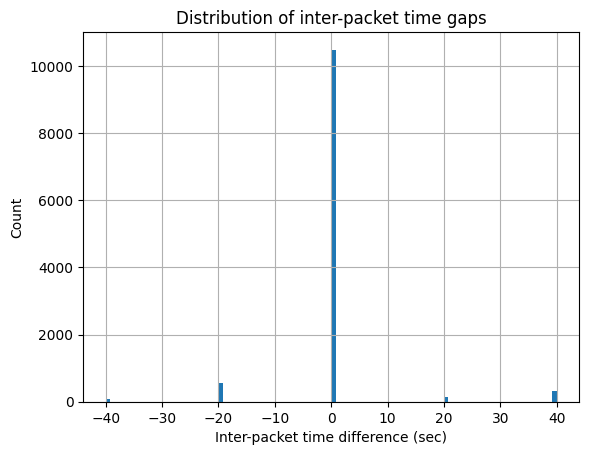

In [296]:
import matplotlib.pyplot as plt
df['time_diff'] = df.groupby(['src_ip', 'dst_ip', "dst_port"])['second'].diff()
df['time_diff'].dropna().hist(bins=100)
plt.xlabel('Inter-packet time difference (sec)')
plt.ylabel('Count')
plt.title('Distribution of inter-packet time gaps')
plt.show()


In [ ]:
import pandas as pd
import numpy as np

TIME_THRESHOLD = 120  # seconds between events

# --- 1. Group into bursts ---
def group_bursts(group):
    group = group.sort_values("timestamp")
    group["iat"] = group["timestamp"].diff().dt.total_seconds().fillna(0)
    burst_id = (group["iat"] > TIME_THRESHOLD).cumsum()
    group["burst_id"] = burst_id
    group["attack_id"] = (
        group["src_ip"].astype(str)
        + "_"
        + group["dst_ip"].astype(str)
        + "_"
        + burst_id.astype(str)
    )
    return group

df_grouped = df.groupby(["src_ip", "dst_ip", "dst_port"], group_keys=False).apply(group_bursts)

# --- 2. Burst-level packet stats ---
group_cols = ["src_ip", "dst_ip", "dst_port", "burst_id", "attack_id"]
burst_packets = df_grouped[group_cols + ["timestamp", "pl_length", "iat", "pl_entropy"]].copy()
burst_packets = burst_packets.sort_values(group_cols + ["timestamp"])

# Burst duration
burst_duration = (
    burst_packets.groupby(group_cols)["timestamp"]
    .agg(["min", "max"])
    .reset_index()
    .rename(columns={"min": "burst_start_time", "max": "burst_end_time"})
)

# Packet length stats
def calculate_burst_stats(group):
    num_packets = group["pl_length"].count()
    stats = {
        "pl_length_count": num_packets,
        "pl_length_sum": group["pl_length"].sum(),
        "pl_length_mean": group["pl_length"].mean(),
        "pl_length_min": group["pl_length"].min(),
        "pl_length_max": group["pl_length"].max(),
        "pl_length_std": group["pl_length"].std() if num_packets > 1 else 0,
        "pl_length_var": group["pl_length"].var() if num_packets > 1 else 0,
    }
    return pd.Series(stats)

burst_stats = burst_packets.groupby(group_cols).apply(calculate_burst_stats).reset_index()

# Idle/IAT stats
def calculate_idle_stats(group):
    valid_diffs = group["iat"][group["iat"] > 0]
    if len(valid_diffs) > 0:
        return pd.Series({
            "Idle Mean": valid_diffs.mean(),
            "Idle Std": valid_diffs.std(),
            "Idle Min": valid_diffs.min(),
            "Idle Max": valid_diffs.max(),
        })
    else:
        return pd.Series({"Idle Mean": 0, "Idle Std": 0, "Idle Min": 0, "Idle Max": 0})

idle_stats = burst_packets.groupby(group_cols).apply(calculate_idle_stats).reset_index()

# --- 3. Merge burst-level stats ---
burst_combined = (
    burst_stats.merge(burst_duration, on=group_cols)
    .merge(idle_stats, on=group_cols)
)

burst_combined["Fwd IAT Total"] = (
    burst_combined["burst_end_time"] - burst_combined["burst_start_time"]
).dt.total_seconds()

# --- 4. CIC-style features ---
burst_combined = burst_combined.rename(columns={
    "pl_length_count": "cic_Total Fwd Packets",
    "pl_length_sum": "cic_Total Length of Fwd Packets",
    "pl_length_mean": "cic_Fwd Packet Length Mean",
    "pl_length_std": "cic_Fwd Packet Length Std",
    "pl_length_var": "cic_Packet Length Variance",
    "pl_length_min": "cic_Fwd Packet Length Min",
    "pl_length_max": "cic_Fwd Packet Length Max",
    "Idle Mean": "cic_Flow IAT Mean",
    "Idle Std": "cic_Flow IAT Std",
    "Idle Max": "cic_Flow IAT Max",
    "Idle Min": "cic_Flow IAT Min",
    "burst_start_time": "burst_min_time",
    "burst_end_time": "burst_max_time"
})

burst_combined["cic_Flow Duration"] = (
    burst_combined["burst_max_time"] - burst_combined["burst_min_time"]
).dt.total_seconds()

flow_duration = burst_combined["cic_Flow Duration"].replace(0, 1)
burst_combined["cic_Flow Bytes/s"] = burst_combined["cic_Total Length of Fwd Packets"] / flow_duration
burst_combined["cic_Flow Packets/s"] = burst_combined["cic_Total Fwd Packets"] / flow_duration
burst_combined["cic_Fwd Packets/s"] = burst_combined["cic_Total Fwd Packets"] / flow_duration

# Some aliases like CIC dataset
burst_combined["cic_Min Packet Length"] = burst_combined["cic_Fwd Packet Length Min"]
burst_combined["cic_Max Packet Length"] = burst_combined["cic_Fwd Packet Length Max"]
burst_combined["cic_Packet Length Mean"] = burst_combined["cic_Fwd Packet Length Mean"]
burst_combined["cic_Packet Length Std"] = burst_combined["cic_Fwd Packet Length Std"]
burst_combined["cic_Average Packet Size"] = burst_combined["cic_Fwd Packet Length Mean"]
burst_combined["cic_Avg Fwd Segment Size"] = burst_combined["cic_Fwd Packet Length Mean"]

for feat in ["Mean", "Std", "Max", "Min"]:
    burst_combined[f"cic_Fwd IAT {feat}"] = burst_combined[f"cic_Flow IAT {feat}"]

# --- 5. Custom aggregations (metadata, payload, etc.) ---
embedding_cols = [col for col in df_grouped.columns if "emb_" in str(col)]
cmd_cols = [col for col in df_grouped.columns if col.startswith("cmd_")]

custom_agg_dict = {
    "hour": "first",
    "day": "first",
    "dst_port": lambda x: list(x.unique()),
    "pl_entropy": ["min", "max", "mean"],
}

for col in cmd_cols:
    custom_agg_dict[col] = "max"

for col in embedding_cols:
    custom_agg_dict[col] = "first"

custom_features = df_grouped.groupby(group_cols).agg(custom_agg_dict)
custom_features.columns = ["_".join(col).strip("_") for col in custom_features.columns.to_flat_index()]
custom_features = custom_features.reset_index()

# --- 6. Merge everything ---
grouped_df = burst_combined.merge(custom_features, on=group_cols, how="left")

grouped_df.shape

In [298]:
grouped_df = grouped_df.drop(columns=["attack_id", "burst_id", "src_ip", "dst_ip", "dst_port_<lambda>", "cic_Fwd IAT Mean", "cic_Fwd IAT Std", "cic_Fwd IAT Max", "cic_Fwd IAT Min","cic_Flow IAT Mean","cic_Flow IAT Std","cic_Flow IAT Min", "cic_Flow IAT Max", "Fwd IAT Total",  "burst_min_time", "burst_max_time"], errors="ignore")

In [299]:
cic_features = [col for col in grouped_df.columns if col.startswith('cic_')]
X_cic = grouped_df[cic_features].copy()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


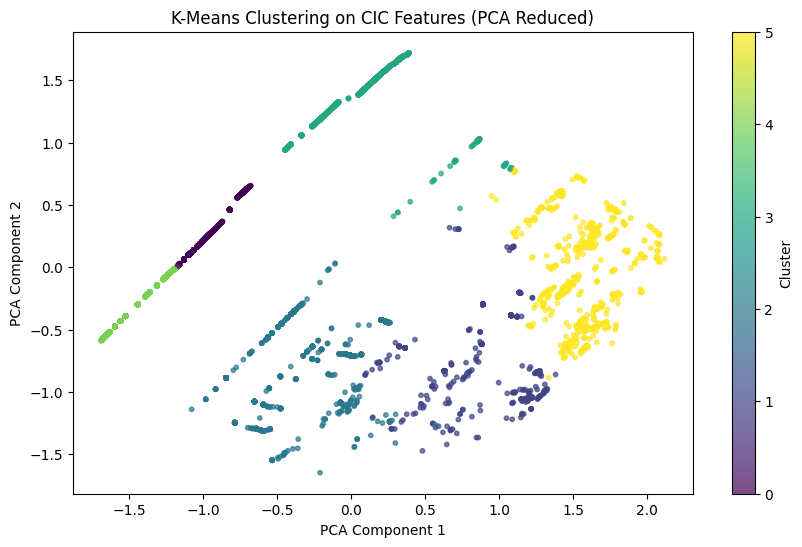

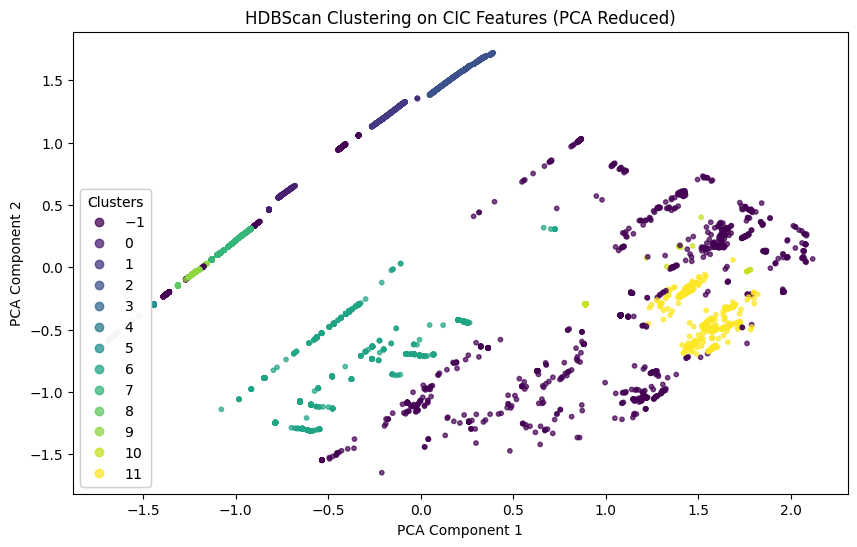

In [300]:
scaler_cic = QuantileTransformer()
X_cic_scaled = scaler_cic.fit_transform(X_cic)

X_cic_scaled_df = pd.DataFrame(X_cic_scaled, columns=cic_features, index=X_cic.index)


# K-means Clustering on CIC features
kmeans_cic = KMeans(n_clusters=6, n_init=10)
kmeans_cic_clusters = kmeans_cic.fit_predict(X_cic_scaled_df)
grouped_df['kmeans_cluster_cic'] = pd.Series(kmeans_cic_clusters, index=X_cic_scaled_df.index)


# HDBScan Clustering on CIC features
hdbscan_cic_clusterer = hdbscan.HDBSCAN(min_cluster_size=200)
hdbscan_cic_clusters = hdbscan_cic_clusterer.fit_predict(X_cic_scaled_df)
grouped_df['hdbscan_cluster_cic'] = pd.Series(hdbscan_cic_clusters, index=X_cic_scaled_df.index)


pca_cic = PCA(n_components=2)
coords_cic = pca_cic.fit_transform(X_cic_scaled_df)

plt.figure(figsize=(10, 6))
plt.scatter(coords_cic[:, 0], coords_cic[:, 1], c=kmeans_cic_clusters, cmap='viridis', alpha=0.7, s=10)
plt.title('K-Means Clustering on CIC Features (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

plt.figure(figsize=(10, 6))
scatter_cic = plt.scatter(coords_cic[:, 0], coords_cic[:, 1], c=hdbscan_cic_clusters, cmap='viridis', alpha=0.7, s=10)
plt.title('HDBScan Clustering on CIC Features (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
legend_cic = plt.legend(*scatter_cic.legend_elements(),
                    loc="lower left", title="Clusters")
plt.gca().add_artist(legend_cic)
plt.show()

Average Silhouette Score for K-Means (CIC): 0.60
Average Silhouette Score for HDBScan (CIC, excluding noise): 0.79


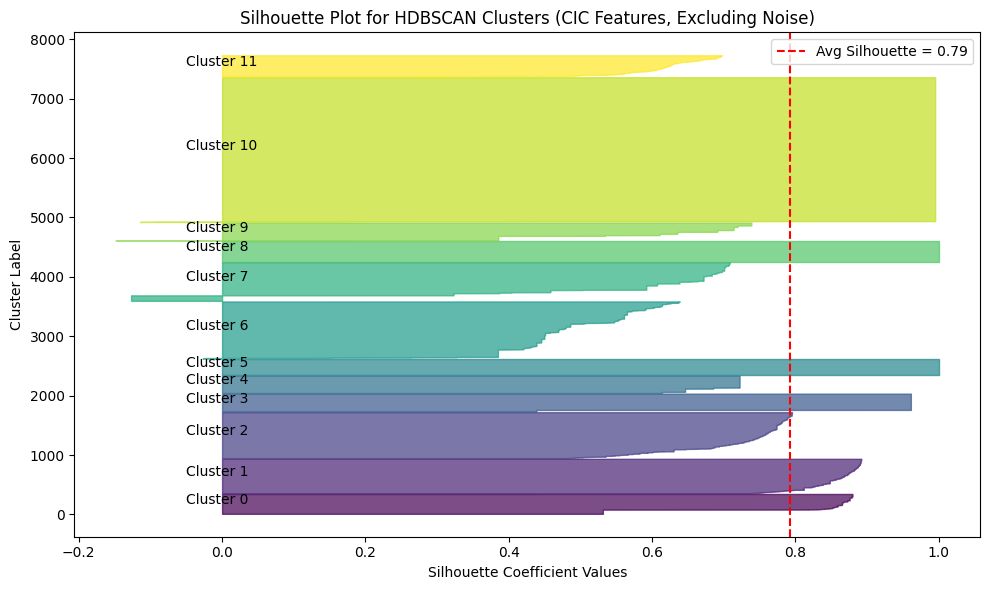

In [301]:
kmeans_silhouette_avg = silhouette_score(X_cic_scaled_df, kmeans_cic_clusters)
print(f"Average Silhouette Score for K-Means (CIC): {kmeans_silhouette_avg:.2f}")

# --- Silhouette for HDBScan on CIC features (excluding noise, label = -1) ---
mask = hdbscan_cic_clusters != -1
X_filtered = X_cic_scaled_df[mask]
labels_filtered = hdbscan_cic_clusters[mask]

if len(np.unique(labels_filtered)) > 1:
    hdbscan_silhouette_avg = silhouette_score(X_filtered, labels_filtered)
    print(f"Average Silhouette Score for HDBScan (CIC, excluding noise): {hdbscan_silhouette_avg:.2f}")

    silhouette_vals = silhouette_samples(X_filtered, labels_filtered)

    sorted_idx = np.argsort(labels_filtered)
    sorted_silhouette_vals = silhouette_vals[sorted_idx]
    sorted_cluster_labels = labels_filtered[sorted_idx]

    # Create silhouette plot
    fig, ax = plt.subplots(figsize=(10, 6))
    y_lower = 10
    unique_labels = np.unique(labels_filtered)

    for label in unique_labels:
        label_sil_vals = sorted_silhouette_vals[sorted_cluster_labels == label]
        label_sil_vals.sort()
        y_upper = y_lower + len(label_sil_vals)

        color = plt.cm.viridis(float(label) / (len(unique_labels) - 1))
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, label_sil_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * len(label_sil_vals), f'Cluster {label}')
        y_lower = y_upper + 10

    # Draw average silhouette score line
    ax.axvline(hdbscan_silhouette_avg, color="red", linestyle="--",
               label=f"Avg Silhouette = {hdbscan_silhouette_avg:.2f}")
    ax.set_title("Silhouette Plot for HDBSCAN Clusters (CIC Features, Excluding Noise)")
    ax.set_xlabel("Silhouette Coefficient Values")
    ax.set_ylabel("Cluster Label")
    ax.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Cannot compute silhouette score for HDBScan on CIC features: only one cluster (excluding noise).")
